In [21]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import json
import random
from dotenv import load_dotenv

from pydrake.all import (
    StartMeshcat,
    DiagramBuilder,
	RollPitchYaw,
    Parser,
    ProcessModelDirectives,
    LoadModelDirectives,
    MultibodyPlant,
    SceneGraph,
    Simulator,
    RigidTransform,
)
from manipulation.station import LoadScenario, MakeHardwareStation

import openai

import sys
sys.path.append("../src")
from ik import IKSolver
from rrt import RRTTools
from motion_planning import *

## Set up OpenAI API Key

The API key is loaded from a `.env` file in the project root. 

**Setup Instructions:**
1. Copy `.env.example` to `.env` in the project root
2. Edit `.env` and replace `your-api-key-here` with your actual OpenAI API key
3. The `.env` file is automatically ignored by git for security

In [2]:
# Load environment variables from .env file
load_dotenv(dotenv_path='../.env')

# Get OpenAI API key from environment
openai.api_key = os.getenv('OPENAI_API_KEY')

if not openai.api_key:
    print("❌ Error: OPENAI_API_KEY not found!")
    print("\nSetup instructions:")
    print("1. Copy .env.example to .env in the project root")
    print("2. Edit .env and add your OpenAI API key")
    print("3. Restart the notebook kernel")
else:
    print("✓ OpenAI API key loaded successfully")

✓ OpenAI API key loaded successfully


## Load Real Kitchen Scene with Drake

Load the kitchen environment using Drake's scenario and extract fruit positions.

In [3]:
# Set up paths
KITCHEN_MODEL_PATH = os.path.abspath("../kitchen_model")
ASSETS_PATH = os.path.abspath("../assets")

# Set environment variables for path substitution
os.environ['KITCHEN_MODEL_PATH'] = KITCHEN_MODEL_PATH
os.environ['ASSETS_PATH'] = ASSETS_PATH

# Start meshcat for visualization
meshcat = StartMeshcat()
print(f"Meshcat listening at {meshcat.web_url()}")

# Load scenario with path substitution
scenario_file = f"{KITCHEN_MODEL_PATH}/real_kitchen_scenario.yaml"

# Read and replace placeholders in the scenario file
with open(scenario_file, 'r') as f:
    scenario_text = f.read()

scenario_text = scenario_text.replace("{KITCHEN_MODEL_PATH}", KITCHEN_MODEL_PATH)
scenario_text = scenario_text.replace("{ASSETS_PATH}", ASSETS_PATH)

# Write to temporary file
import tempfile
with tempfile.NamedTemporaryFile(mode='w', suffix='.yaml', delete=False) as tmp:
    tmp.write(scenario_text)
    tmp_scenario_file = tmp.name

scenario = LoadScenario(filename=tmp_scenario_file)

# Create the station
station = MakeHardwareStation(scenario, meshcat)
plant = station.GetSubsystemByName("plant")
scene_graph = station.GetSubsystemByName("scene_graph")

# Clean up temp file
os.unlink(tmp_scenario_file)

print(f"✓ Loaded plant with {plant.num_bodies()} bodies")

# Run physics simulation to let fruits fall and settle
print("\nSimulating physics to let fruits settle...")
sim_temp = Simulator(station)
sim_temp.Initialize()

# Get the settled positions from the simulation
context = sim_temp.get_context()
plant_context = plant.GetMyContextFromRoot(context)

# Initialize robot at the starting position with straight arm configuration
print("\n📍 Initializing robot configuration...")
try:
    # Get the mobile_iiwa model instance
    mobile_iiwa = plant.GetModelInstanceByName("mobile_iiwa")
    num_positions = plant.num_positions(mobile_iiwa)
    
    print(f"mobile_iiwa has {num_positions} DOFs")
    
    # Robot starting position
    robot_start_x = -4.0
    robot_start_y = -1.0
    
    # Get joint indices
    base_x_joint = plant.GetJointByName("iiwa_base_x", mobile_iiwa)
    base_y_joint = plant.GetJointByName("iiwa_base_y", mobile_iiwa)
    base_z_joint = plant.GetJointByName("iiwa_base_z", mobile_iiwa)
    
    base_x_idx = base_x_joint.position_start()
    base_y_idx = base_y_joint.position_start()
    base_z_idx = base_z_joint.position_start()
    
    # Create position array for mobile_iiwa only (doesn't affect fruits!)
    robot_positions = np.zeros(num_positions)
    robot_positions[base_x_idx] = robot_start_x
    robot_positions[base_y_idx] = robot_start_y
    robot_positions[base_z_idx] = 0.1  # Height
    # All arm joints default to 0 (straight configuration)
    
    # Set only the robot positions (fruits are separate model instances)
    plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
    
    # Force visualization update
    station.ForcedPublish(context)
    
    print(f"✓ Robot initialized:")
    print(f"   Base position: ({robot_start_x}, {robot_start_y}, 0.1)")
    print(f"   All arm joints: 0 (straight configuration)")
        
except Exception as e:
    print(f"⚠ Could not initialize robot configuration: {e}")
    print("  Continuing with default configuration...")

# Extract fruit positions

kitchen_map = KitchenMap(plant, plant_context).map
print(f"\n✓ Kitchen map created with {kitchen_map} fruits")
print("\nKitchen Map:")
print(json.dumps(kitchen_map, indent=2))

INFO:drake:Meshcat listening for connections at http://localhost:7002


Meshcat listening at http://localhost:7002


✓ Loaded plant with 29 bodies

Simulating physics to let fruits settle...

📍 Initializing robot configuration...
mobile_iiwa has 10 DOFs
✓ Robot initialized:
   Base position: (-4.0, -1.0, 0.1)
   All arm joints: 0 (straight configuration)
✓ Updated kitchen map (5 objects)

✓ Kitchen map created with {'apple': {'position': [-4.5, -1.5, 0.95], 'x': -4.5, 'y': -1.5, 'z': 0.95}, 'banana': {'position': [-5.7, -2.0, 0.95], 'x': -5.7, 'y': -2.0, 'z': 0.95}, 'lemon': {'position': [-4.3, -3.15, 0.95], 'x': -4.3, 'y': -3.15, 'z': 0.95}, 'orange': {'position': [-5.3, -2.0, 0.95], 'x': -5.3, 'y': -2.0, 'z': 0.95}, 'peach': {'position': [-5.4, -3.15, 0.95], 'x': -5.4, 'y': -3.15, 'z': 0.95}} fruits

Kitchen Map:
{
  "apple": {
    "position": [
      -4.5,
      -1.5,
      0.95
    ],
    "x": -4.5,
    "y": -1.5,
    "z": 0.95
  },
  "banana": {
    "position": [
      -5.7,
      -2.0,
      0.95
    ],
    "x": -5.7,
    "y": -2.0,
    "z": 0.95
  },
  "lemon": {
    "position": [
      -4.3,


## GPT-4o Query Function

Create a function to query GPT-4o with manipulation commands.

In [4]:
grid_info = load_kitchen_grid("../data", waypoint_resolution=0.2)
rrt = RRTPlanner(grid_info, step_size=0.3, max_iterations=5000, goal_sample_rate=0.15)

In [10]:
grid_info

{'occupancy_grid': array([[1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
         1, 1, 1],
        [1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 

In [11]:
x_positions = grid_info['x_positions']
y_positions = grid_info['y_positions']
occupancy_grid = grid_info['occupancy_grid']
X_MIN, X_MAX, Y_MIN, Y_MAX = grid_info['bounds']

## Load Occupancy Grid and Setup RRT Planner

Load the pre-computed occupancy grid and create an RRT planner for navigation.

In [12]:
def query_gpt_for_manipulation(command: str, kitchen_map: dict) -> dict:
    """
    Query GPT-4o-mini to interpret a manipulation command and identify the object and target.
    
    Args:
        command: Natural language command (e.g., "Put apple beside the banana")
        kitchen_map: Dictionary mapping fruit names to their positions
    
    Returns:
        Dictionary with 'object', 'target_object', and 'relationship' keys
    """
    
    # Create the prompt for GPT-4o-mini
    prompt = f"""You are a robotic manipulation assistant. Given a kitchen map with fruit positions and a manipulation command, determine:
1. Which object to manipulate (object_to_move)
2. The target/reference object (target_object)
3. The spatial relationship (e.g., "beside", "next to", "near")

Kitchen Map (available objects):
{json.dumps(list(kitchen_map.keys()), indent=2)}

Command: {command}

Respond ONLY with a valid JSON object in this exact format:
{{
    "object_to_move": "name_of_object_to_move",
    "target_object": "name_of_reference_object",
    "relationship": "beside|next_to|near",
    "reasoning": "brief explanation"
}}

Example: For "Put apple beside the banana", respond with:
{{
    "object_to_move": "apple",
    "target_object": "banana",
    "relationship": "beside",
    "reasoning": "Move apple to be beside banana"
}}
"""

    try:
        # Call GPT-4o-mini API (new OpenAI v1.0+ syntax)
        from openai import OpenAI
        client = OpenAI(api_key=openai.api_key)
        
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "You are a robotic manipulation expert. Always respond with valid JSON. Only identify objects and relationships, do not calculate positions."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,
            max_tokens=300
        )
        
        # Extract and parse the response
        response_text = response.choices[0].message.content.strip()
        
        # Remove code blocks if present
        if response_text.startswith('```'):
            response_text = response_text.split('```')[1]
            if response_text.startswith('json'):
                response_text = response_text[4:]
            response_text = response_text.strip()
        
        result = json.loads(response_text)
        
        return result
        
    except Exception as e:
        print(f"❌ Error querying GPT-4o-mini: {e}")
        return None

def calculate_target_position(object_pos, target_pos, relationship="beside"):
    """
    Calculate the target position based on the relationship to the reference object.
    Uses 2D grid-based planning.
    
    Args:
        object_pos: Current position [x, y, z] of object to move
        target_pos: Position [x, y, z] of reference object
        relationship: Spatial relationship ("beside", "next_to", "near")
    
    Returns:
        Target position [x, y, z]
    """
    # For "beside"/"next to"/"near", place object approximately 0.15-0.2m away
    offset_distance = 0.18
    
    # Keep same z-coordinate (height) as target object
    target_z = target_pos[2]
    
    # Place to the right of target object (positive x direction)
    target_x = target_pos[0] + offset_distance
    target_y = target_pos[1]
    
    return [target_x, target_y, target_z]

print("✓ GPT-4o-mini query function and position calculation defined")


✓ GPT-4o-mini query function and position calculation defined


## Test: Put Apple Beside Banana

In [36]:
# Test the manipulation command with navigation
command = "Put apple beside the banana"
# command = "Put banana beside the orange"

print(f"Command: {command}\n")

# Step 1: Get object identification from GPT
gpt_result = query_gpt_for_manipulation(command, kitchen_map)

if gpt_result:
    print("\n✓ GPT-4o Response:")
    print(json.dumps(gpt_result, indent=2))
    
    # Step 2: Get actual positions from kitchen map
    object_to_move = gpt_result['object_to_move']
    target_object = gpt_result['target_object']
    
    if object_to_move not in kitchen_map:
        print(f"❌ Error: '{object_to_move}' not found in kitchen map")
        manipulation_result = None
    elif target_object not in kitchen_map:
        print(f"❌ Error: '{target_object}' not found in kitchen map")
        manipulation_result = None
    else:
        object_pos = kitchen_map[object_to_move]['position']
        target_pos = kitchen_map[target_object]['position']
        
        # Step 3: Calculate target position using grid-based method
        relationship = gpt_result.get('relationship', 'beside')
        end_position = calculate_target_position(object_pos, target_pos, relationship)
        
        print("\n" + "="*60)
        print("MANIPULATION TASK")
        print("="*60)
        print(f"Object to move: {object_to_move}")
        print(f"Target object:  {target_object}")
        print(f"Relationship:   {relationship}")
        print(f"Start position (current): {object_pos}")
        print(f"End position (calculated): {end_position}")
        print(f"Reasoning: {gpt_result.get('reasoning', 'N/A')}")
        print("="*60)
        
        # Step 4: Find nearest free waypoints if positions are in collision
        print("\n" + "="*60)
        print("COLLISION CHECKING & WAYPOINT ADJUSTMENT")
        print("="*60)
        
        # Generate free waypoints for nearest neighbor search
        free_waypoints = []
        for i, x in enumerate(x_positions):
            for j, y in enumerate(y_positions):
                if occupancy_grid[j, i] == 0:
                    free_waypoints.append((x, y))
        free_waypoints = np.array(free_waypoints)
        
        from scipy.spatial import KDTree
        kdtree = KDTree(free_waypoints)
        
        # Check pickup position
        pickup_pos_original = (object_pos[0], object_pos[1])
        pickup_is_free = rrt.is_collision_free(pickup_pos_original[0], pickup_pos_original[1])
        
        if not pickup_is_free:
            distance, idx = kdtree.query(pickup_pos_original)
            pickup_pos = tuple(free_waypoints[idx])
            print(f"⚠ Pickup position {pickup_pos_original} is in collision!")
            print(f"  Using nearest free waypoint: {pickup_pos} (distance: {distance:.3f}m)")
        else:
            pickup_pos = pickup_pos_original
            print(f"✓ Pickup position {pickup_pos} is collision-free")
        
        # Check dropoff position
        dropoff_pos_original = (end_position[0], end_position[1])
        dropoff_is_free = rrt.is_collision_free(dropoff_pos_original[0], dropoff_pos_original[1])
        
        if not dropoff_is_free:
            distance, idx = kdtree.query(dropoff_pos_original)
            dropoff_pos = tuple(free_waypoints[idx])
            print(f"⚠ Drop-off position {dropoff_pos_original} is in collision!")
            print(f"  Using nearest free waypoint: {dropoff_pos} (distance: {distance:.3f}m)")
        else:
            dropoff_pos = dropoff_pos_original
            print(f"✓ Drop-off position {dropoff_pos} is collision-free")
        
        print("="*60)
        
        # Step 5: Plan navigation paths using 2D grid
        print("\n" + "="*60)
        print("NAVIGATION PLANNING (2D Grid-based RRT)")
        print("="*60)
        
        # Robot starts at initial position
        robot_start = (-4.0, -1.0)  # Initial robot position
        
        print(f"\nRobot start: {robot_start}")
        print(f"Pickup waypoint ({object_to_move}): {pickup_pos}")
        print(f"Drop-off waypoint (beside {target_object}): {dropoff_pos}")
        
        # Plan path 1: Robot start -> Pickup location (using 2D grid)
        print(f"\n📍 Planning path 1: Robot → {object_to_move} pickup waypoint...")
        path_to_pickup = rrt.plan(robot_start, pickup_pos)
        
        if path_to_pickup:
            print(f"✓ Path found with {len(path_to_pickup)} waypoints")
        else:
            print("❌ Failed to find path to pickup location")
        
        # Plan path 2: Pickup location -> Drop-off location (using 2D grid)
        print(f"\n📍 Planning path 2: Pickup waypoint → Drop-off waypoint (beside {target_object})...")
        path_to_dropoff = rrt.plan(pickup_pos, dropoff_pos)
        
        if path_to_dropoff:
            print(f"✓ Path found with {len(path_to_dropoff)} waypoints")
        else:
            print("❌ Failed to find path to drop-off location")
        
        # Store results for visualization
        manipulation_result = {
            'gpt_response': gpt_result,
            'object_to_move': object_to_move,
            'target_object': target_object,
            'start_position': object_pos,
            'end_position': end_position,
            'robot_start': robot_start,
            'pickup_pos': pickup_pos,
            'pickup_pos_original': pickup_pos_original,
            'pickup_adjusted': not pickup_is_free,
            'dropoff_pos': dropoff_pos,
            'dropoff_pos_original': dropoff_pos_original,
            'dropoff_adjusted': not dropoff_is_free,
            'path_to_pickup': path_to_pickup,
            'path_to_dropoff': path_to_dropoff
        }
        
        print("\n" + "="*60)
        if path_to_pickup and path_to_dropoff:
            total_waypoints = len(path_to_pickup) + len(path_to_dropoff) - 1  # -1 for duplicate
            print(f"✓ Complete navigation plan ready!")
            print(f"  Total waypoints: {total_waypoints}")
            print(f"  Method: 2D occupancy grid with RRT + nearest waypoint adjustment")
        else:
            print("⚠ Navigation planning incomplete")
        print("="*60)
    
else:
    print("❌ Failed to get response from GPT-4o")
    manipulation_result = None


Command: Put apple beside the banana


✓ GPT-4o Response:
{
  "object_to_move": "apple",
  "target_object": "banana",
  "relationship": "beside",
  "reasoning": "Move apple to be beside banana"
}

MANIPULATION TASK
Object to move: apple
Target object:  banana
Relationship:   beside
Start position (current): [-4.5, -1.5, 0.95]
End position (calculated): [-5.5200000000000005, -2.0, 0.95]
Reasoning: Move apple to be beside banana

COLLISION CHECKING & WAYPOINT ADJUSTMENT
⚠ Pickup position (-4.5, -1.5) is in collision!
  Using nearest free waypoint: (np.float64(-4.299999999999997), np.float64(-1.5999999999999988)) (distance: 0.224m)
⚠ Drop-off position (-5.5200000000000005, -2.0) is in collision!
  Using nearest free waypoint: (np.float64(-5.499999999999998), np.float64(-2.3999999999999995)) (distance: 0.400m)

NAVIGATION PLANNING (2D Grid-based RRT)

Robot start: (-4.0, -1.0)
Pickup waypoint (apple): (np.float64(-4.299999999999997), np.float64(-1.5999999999999988))
Drop-off waypoint (besi

## Visualize All Available Waypoints

Show all free waypoints on the occupancy grid to understand the navigable space.


Total free waypoints: 279
Grid dimensions: (20, 25)
Total grid cells: 500
Occupied cells: 221
Free cells: 279

NEAREST FREE WAYPOINTS TO EACH FRUIT
apple     : (-4.5, -1.5) [✗ COLLISION]
           Nearest waypoint: (np.float64(-4.299999999999997), np.float64(-1.5999999999999988)) (distance: 0.224m)
banana    : (-5.7, -2.0) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.699999999999998), np.float64(-2.3999999999999995)) (distance: 0.400m)
lemon     : (-4.3, -3.15) [✗ COLLISION]
           Nearest waypoint: (np.float64(-4.299999999999997), np.float64(-2.8)) (distance: 0.350m)
orange    : (-5.3, -2.0) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.299999999999998), np.float64(-2.3999999999999995)) (distance: 0.400m)
peach     : (-5.4, -3.15) [✗ COLLISION]
           Nearest waypoint: (np.float64(-5.699999999999998), np.float64(-3.0)) (distance: 0.335m)


/var/folders/26/txjfqjd52svf9l_j4txvmyc40000gn/T/ipykernel_50093/4105874766.py:69: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, s=300, c=color, marker=marker,


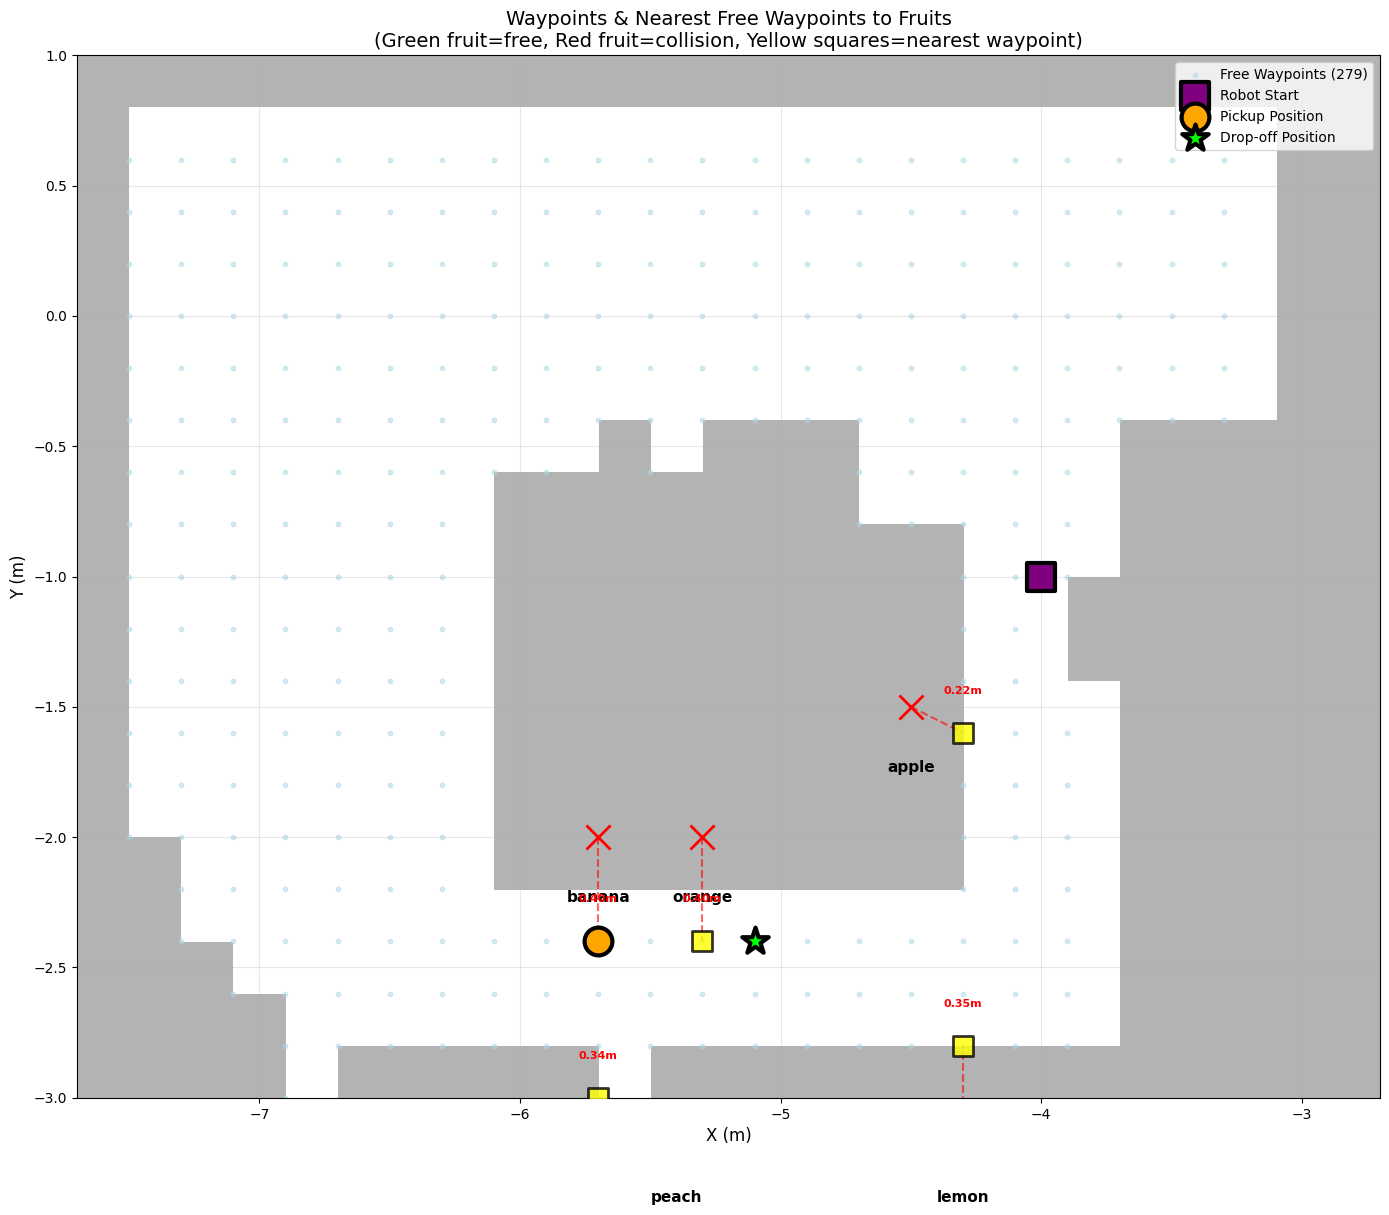


✓ Waypoint visualization complete


In [14]:
# Generate all free waypoints from the occupancy grid
free_waypoints = []

for i, x in enumerate(x_positions):
    for j, y in enumerate(y_positions):
        if occupancy_grid[j, i] == 0:  # Free space
            free_waypoints.append((x, y))

free_waypoints = np.array(free_waypoints)

print(f"Total free waypoints: {len(free_waypoints)}")
print(f"Grid dimensions: {occupancy_grid.shape}")
print(f"Total grid cells: {occupancy_grid.shape[0] * occupancy_grid.shape[1]}")
print(f"Occupied cells: {np.sum(occupancy_grid > 0)}")
print(f"Free cells: {np.sum(occupancy_grid == 0)}")

# Find nearest free waypoints to each fruit
print("\n" + "="*60)
print("NEAREST FREE WAYPOINTS TO EACH FRUIT")
print("="*60)

from scipy.spatial import KDTree
kdtree = KDTree(free_waypoints)

fruit_nearest_waypoints = {}
for fruit_name, fruit_data in kitchen_map.items():
    fruit_pos = (fruit_data['x'], fruit_data['y'])
    
    # Check if fruit position itself is free
    is_free = rrt.is_collision_free(fruit_pos[0], fruit_pos[1])
    
    # Find nearest free waypoint
    distance, idx = kdtree.query(fruit_pos)
    nearest_waypoint = tuple(free_waypoints[idx])
    
    fruit_nearest_waypoints[fruit_name] = {
        'fruit_pos': fruit_pos,
        'is_collision_free': is_free,
        'nearest_waypoint': nearest_waypoint,
        'distance': distance
    }
    
    status = "✓ FREE" if is_free else "✗ COLLISION"
    print(f"{fruit_name:10s}: {fruit_pos} [{status}]")
    print(f"           Nearest waypoint: {nearest_waypoint} (distance: {distance:.3f}m)")

print("="*60)

# Visualize all waypoints with nearest waypoints to fruits highlighted
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

# Plot occupancy grid
ax.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
          extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.3, interpolation='nearest')

# Plot all free waypoints
if len(free_waypoints) > 0:
    ax.scatter(free_waypoints[:, 0], free_waypoints[:, 1], 
              s=10, c='lightblue', alpha=0.5, label=f'Free Waypoints ({len(free_waypoints)})')

# Plot all fruit positions and their nearest waypoints
for fruit_name, fruit_data in kitchen_map.items():
    x, y = fruit_data['x'], fruit_data['y']
    info = fruit_nearest_waypoints[fruit_name]
    
    # Fruit position
    color = 'green' if info['is_collision_free'] else 'red'
    marker = 'o' if info['is_collision_free'] else 'x'
    ax.scatter(x, y, s=300, c=color, marker=marker, 
              edgecolors='black', linewidth=2, zorder=5)
    ax.text(x, y-0.25, fruit_name, ha='center', fontsize=11, fontweight='bold')
    
    # Nearest waypoint
    nearest_wp = info['nearest_waypoint']
    ax.scatter(nearest_wp[0], nearest_wp[1], s=200, c='yellow', marker='s', 
              edgecolors='black', linewidth=2, zorder=5, alpha=0.8)
    
    # Draw line from fruit to nearest waypoint
    ax.plot([x, nearest_wp[0]], [y, nearest_wp[1]], 'r--', linewidth=1.5, alpha=0.6)
    ax.text(nearest_wp[0], nearest_wp[1]+0.15, f"{info['distance']:.2f}m", 
           ha='center', fontsize=8, color='red', fontweight='bold')

# Plot robot start and targets if manipulation_result exists
if manipulation_result:
    robot_start = manipulation_result['robot_start']
    ax.scatter(*robot_start, s=400, c='purple', marker='s', 
              edgecolors='black', linewidth=3, label='Robot Start', zorder=6)
    
    pickup_pos = manipulation_result['pickup_pos']
    ax.scatter(*pickup_pos, s=400, c='orange', marker='o', 
              edgecolors='black', linewidth=3, label='Pickup Position', zorder=6)
    
    dropoff_pos = manipulation_result['dropoff_pos']
    ax.scatter(*dropoff_pos, s=400, c='lime', marker='*', 
              edgecolors='black', linewidth=3, label='Drop-off Position', zorder=6)

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X (m)', fontsize=12)
ax.set_ylabel('Y (m)', fontsize=12)
ax.set_title('Waypoints & Nearest Free Waypoints to Fruits\n(Green fruit=free, Red fruit=collision, Yellow squares=nearest waypoint)', fontsize=14)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print("\n✓ Waypoint visualization complete")


## Visualize the Movement

Show the start and end positions visually.

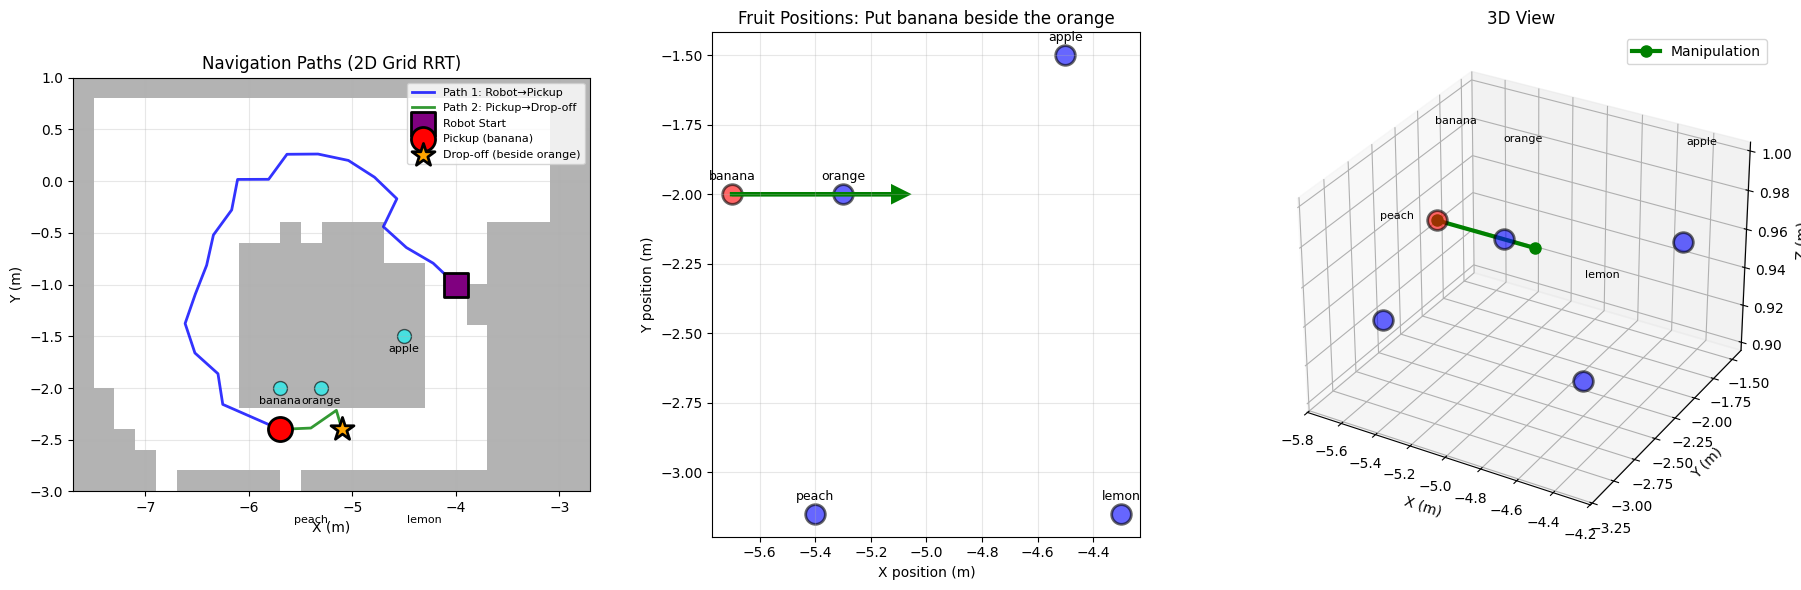

✓ Visualization complete

EXECUTION SUMMARY (2D Grid-based Planning)
1. Robot navigates from (-4.0, -1.0) to (np.float64(-5.699999999999998), np.float64(-2.3999999999999995))
   (22 waypoints via 2D grid RRT)
2. Robot picks up banana
3. Robot navigates from (np.float64(-5.699999999999998), np.float64(-2.3999999999999995)) to (np.float64(-5.099999999999998), np.float64(-2.3999999999999995))
   (4 waypoints via 2D grid RRT)
4. Robot places banana beside orange


In [15]:
if manipulation_result:
    path_to_pickup = manipulation_result.get('path_to_pickup')
    path_to_dropoff = manipulation_result.get('path_to_dropoff')
    
    if path_to_pickup is None or path_to_dropoff is None:
        print("⚠ Cannot visualize - navigation planning failed")
        if path_to_pickup is None:
            print("  - Path to pickup could not be found (collision or unreachable)")
        if path_to_dropoff is None:
            print("  - Path to drop-off could not be found (collision or unreachable)")
    else:
        robot_start = manipulation_result['robot_start']
        pickup_pos = manipulation_result['pickup_pos']
        dropoff_pos = manipulation_result['dropoff_pos']
        object_to_move = manipulation_result['object_to_move']
        target_object = manipulation_result['target_object']
        start_pos = manipulation_result['start_position']
        end_pos = manipulation_result['end_position']
        
        fig = plt.figure(figsize=(18, 6))
        
        # 1. Occupancy grid with navigation paths (2D grid-based planning)
        ax1 = fig.add_subplot(131)
        
        # Plot occupancy grid
        ax1.imshow(occupancy_grid, cmap='gray_r', origin='lower', 
                   extent=[X_MIN, X_MAX, Y_MIN, Y_MAX], alpha=0.3, interpolation='nearest')
        
        # Plot navigation paths (from 2D grid RRT)
        path1_array = np.array(path_to_pickup)
        path2_array = np.array(path_to_dropoff)
        
        ax1.plot(path1_array[:, 0], path1_array[:, 1], 'b-', linewidth=2, label='Path 1: Robot→Pickup', alpha=0.8)
        ax1.plot(path2_array[:, 0], path2_array[:, 1], 'g-', linewidth=2, label='Path 2: Pickup→Drop-off', alpha=0.8)
        
        # Mark key locations
        ax1.scatter(*robot_start, s=300, c='purple', marker='s', edgecolors='black', linewidth=2, label='Robot Start', zorder=5)
        ax1.scatter(*pickup_pos, s=300, c='red', marker='o', edgecolors='black', linewidth=2, label=f'Pickup ({object_to_move})', zorder=5)
        ax1.scatter(*dropoff_pos, s=300, c='orange', marker='*', edgecolors='black', linewidth=2, label=f'Drop-off (beside {target_object})', zorder=5)
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y = fruit_data['x'], fruit_data['y']
            ax1.scatter(x, y, s=100, c='cyan', alpha=0.6, edgecolors='black', linewidth=1)
            ax1.text(x, y-0.15, fruit_name, ha='center', fontsize=8)
        
        ax1.set_xlim(X_MIN, X_MAX)
        ax1.set_ylim(Y_MIN, Y_MAX)
        ax1.set_xlabel('X (m)')
        ax1.set_ylabel('Y (m)')
        ax1.set_title('Navigation Paths (2D Grid RRT)')
        ax1.legend(fontsize=8, loc='upper right')
        ax1.grid(True, alpha=0.3)
        ax1.set_aspect('equal')
        
        # 2. Top-down fruit map view
        ax2 = fig.add_subplot(132)
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y = fruit_data['x'], fruit_data['y']
            color = 'red' if fruit_name == object_to_move else 'blue'
            ax2.scatter(x, y, s=200, c=color, alpha=0.6, edgecolors='black', linewidth=2)
            ax2.text(x, y+0.05, fruit_name, ha='center', fontsize=9)
        
        # Plot manipulation arrow
        ax2.arrow(start_pos[0], start_pos[1], end_pos[0]-start_pos[0], end_pos[1]-start_pos[1],
                  head_width=0.05, head_length=0.05, fc='green', ec='green', linewidth=3)
        
        ax2.set_xlabel('X position (m)')
        ax2.set_ylabel('Y position (m)')
        ax2.set_title(f'Fruit Positions: {command}')
        ax2.grid(True, alpha=0.3)
        ax2.set_aspect('equal')
        
        # 3. 3D view
        ax3 = fig.add_subplot(133, projection='3d')
        
        # Plot all fruits
        for fruit_name, fruit_data in kitchen_map.items():
            x, y, z = fruit_data['x'], fruit_data['y'], fruit_data['z']
            color = 'red' if fruit_name == object_to_move else 'blue'
            ax3.scatter(x, y, z, s=200, c=color, alpha=0.6, edgecolors='black', linewidth=2)
            ax3.text(x, y, z+0.05, fruit_name, fontsize=8)
        
        # Plot manipulation movement
        ax3.plot([start_pos[0], end_pos[0]], [start_pos[1], end_pos[1]], [start_pos[2], end_pos[2]],
                 'g-', linewidth=3, marker='o', markersize=8, label='Manipulation')
        
        ax3.set_xlabel('X (m)')
        ax3.set_ylabel('Y (m)')
        ax3.set_zlabel('Z (m)')
        ax3.set_title('3D View')
        ax3.legend()
        
        plt.tight_layout()
        plt.show()
        
        print("✓ Visualization complete")
        
        # Print summary
        print("\n" + "="*60)
        print("EXECUTION SUMMARY (2D Grid-based Planning)")
        print("="*60)
        print(f"1. Robot navigates from {robot_start} to {pickup_pos}")
        print(f"   ({len(path_to_pickup)} waypoints via 2D grid RRT)")
        print(f"2. Robot picks up {object_to_move}")
        print(f"3. Robot navigates from {pickup_pos} to {dropoff_pos}")
        print(f"   ({len(path_to_dropoff)} waypoints via 2D grid RRT)")
        print(f"4. Robot places {object_to_move} beside {target_object}")
        print("="*60)
else:
    print("⚠ No manipulation result available")


## Execute Manipulation in Drake

Animate the robot following the planned path in Drake's Meshcat visualizer.


In [16]:
if manipulation_result and manipulation_result.get('path_to_pickup') and manipulation_result.get('path_to_dropoff'):
    from pydrake.all import Simulator, DiagramBuilder
    
    print("="*60)
    print("EXECUTING MANIPULATION IN DRAKE")
    print("="*60)
    
    # Get the paths
    path_to_pickup = manipulation_result['path_to_pickup']
    path_to_dropoff = manipulation_result['path_to_dropoff']
    
    # Combine paths (remove duplicate waypoint at pickup location)
    full_path = list(path_to_pickup) + list(path_to_dropoff)[1:]
    
    print(f"\nTotal navigation waypoints: {len(full_path)}")
    print(f"  Path 1 (Robot → Pickup): {len(path_to_pickup)} waypoints")
    print(f"  Path 2 (Pickup → Drop-off): {len(path_to_dropoff)} waypoints")
    
    # Create a new simulator for animation
    sim = Simulator(station)
    sim.Initialize()
    
    # Get contexts
    context = sim.get_mutable_context()
    plant_context = plant.GetMyMutableContextFromRoot(context)
    
    # Set all robot joints to zero and initialize base position
    print("\n📍 Setting robot configuration for animation...")
    
    # Get the mobile_iiwa model instance
    mobile_iiwa = plant.GetModelInstanceByName("mobile_iiwa")
    num_positions = plant.num_positions(mobile_iiwa)
    
    print(f"mobile_iiwa has {num_positions} DOFs")
    
    # Get the starting position from the path
    robot_start = manipulation_result['robot_start']
    
    # Get joint indices
    base_x_joint = plant.GetJointByName("iiwa_base_x", mobile_iiwa)
    base_y_joint = plant.GetJointByName("iiwa_base_y", mobile_iiwa)
    base_z_joint = plant.GetJointByName("iiwa_base_z", mobile_iiwa)
    
    base_x_idx = base_x_joint.position_start()
    base_y_idx = base_y_joint.position_start()
    base_z_idx = base_z_joint.position_start()
    
    # Create position array for mobile_iiwa only
    robot_positions = np.zeros(num_positions)
    robot_positions[base_x_idx] = robot_start[0]
    robot_positions[base_y_idx] = robot_start[1]
    robot_positions[base_z_idx] = 0.1  # Height
    # All arm joints default to 0 (straight configuration)
    
    # Set only the robot positions
    plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
    
    print(f"✓ Robot configuration set:")
    print(f"  Base position: ({robot_start[0]:.2f}, {robot_start[1]:.2f}, 0.1)")
    print(f"  All arm joints: 0 (straight configuration)")
    
    # Start recording in Meshcat
    meshcat.StartRecording()
    print("\n🎬 Started recording animation in Meshcat")
    
    # Animate through the path
    print(f"\n🤖 Animating robot movement...")
    time_per_waypoint = 0.5  # seconds per waypoint
    
    for i, waypoint in enumerate(full_path):
        # Update robot position for this waypoint
        robot_positions = np.zeros(num_positions)
        robot_positions[base_x_idx] = waypoint[0]  # base x
        robot_positions[base_y_idx] = waypoint[1]  # base y
        robot_positions[base_z_idx] = 0.1  # Height
        # All arm joints stay at 0 (straight configuration)
        
        # Set only the robot positions (doesn't affect fruits)
        plant.SetPositions(plant_context, mobile_iiwa, robot_positions)
        
        # Advance time and publish
        sim_time = i * time_per_waypoint
        context.SetTime(sim_time)
        
        # Force diagram to publish (update visualization)
        station.ForcedPublish(context)
        
        # Print progress
        if i == 0:
            print(f"  Waypoint {i+1}/{len(full_path)}: Robot start {waypoint}")
        elif i == len(path_to_pickup) - 1:
            print(f"  Waypoint {i+1}/{len(full_path)}: Reached pickup location {waypoint}")
        elif i == len(full_path) - 1:
            print(f"  Waypoint {i+1}/{len(full_path)}: Reached drop-off location {waypoint}")
    
    # Stop recording
    meshcat.StopRecording()
    print("\n✓ Animation complete!")
    
    # Publish recording
    meshcat.PublishRecording()
    print(f"\n🎥 Animation published to Meshcat: {meshcat.web_url()}")
    print("   You can replay the animation in the Meshcat viewer")
    
    print("\n" + "="*60)
    print("ANIMATION SUMMARY")
    print("="*60)
    print(f"Total waypoints: {len(full_path)}")
    print(f"Animation duration: {len(full_path) * time_per_waypoint:.1f} seconds")
    print(f"Time per waypoint: {time_per_waypoint} seconds")
    print("="*60)
    
else:
    print("⚠ Cannot execute - no valid path available")
    print("   Run the planning cell first to generate paths")


EXECUTING MANIPULATION IN DRAKE

Total navigation waypoints: 25
  Path 1 (Robot → Pickup): 22 waypoints
  Path 2 (Pickup → Drop-off): 4 waypoints

📍 Setting robot configuration for animation...
mobile_iiwa has 10 DOFs
✓ Robot configuration set:
  Base position: (-4.00, -1.00, 0.1)
  All arm joints: 0 (straight configuration)

🎬 Started recording animation in Meshcat

🤖 Animating robot movement...
  Waypoint 1/25: Robot start (np.float64(-4.0), np.float64(-1.0))
  Waypoint 22/25: Reached pickup location (np.float64(-5.699999999999998), np.float64(-2.3999999999999995))
  Waypoint 25/25: Reached drop-off location (np.float64(-5.099999999999998), np.float64(-2.3999999999999995))

✓ Animation complete!

🎥 Animation published to Meshcat: http://localhost:7002
   You can replay the animation in the Meshcat viewer

ANIMATION SUMMARY
Total waypoints: 25
Animation duration: 12.5 seconds
Time per waypoint: 0.5 seconds


## Try Other Commands

Test the system with different manipulation commands.

In [17]:
# Try different commands
test_commands = [
    "Put the lemon next to the orange",
    "Move the peach beside the banana",
]

for cmd in test_commands:
    print(f"\n{'='*60}")
    print(f"Command: {cmd}")
    print('='*60)
    
    gpt_result = query_gpt_for_manipulation(cmd, kitchen_map)
    
    if gpt_result:
        object_to_move = gpt_result['object_to_move']
        target_object = gpt_result['target_object']
        
        if object_to_move in kitchen_map and target_object in kitchen_map:
            object_pos = kitchen_map[object_to_move]['position']
            target_pos = kitchen_map[target_object]['position']
            end_pos = calculate_target_position(object_pos, target_pos, gpt_result.get('relationship', 'beside'))
            
            print(f"Object:  {object_to_move}")
            print(f"Target:  {target_object}")
            print(f"Start:   {object_pos}")
            print(f"End:     {end_pos} (calculated via 2D grid)")
            print(f"Reason:  {gpt_result.get('reasoning', 'N/A')}")
        else:
            print(f"❌ Object not found in kitchen map")
    else:
        print("❌ Failed to process command")



Command: Put the lemon next to the orange
Object:  lemon
Target:  orange
Start:   [-4.3, -3.15, 0.95]
End:     [-5.12, -2.0, 0.95] (calculated via 2D grid)
Reason:  Move lemon to be next to orange

Command: Move the peach beside the banana
Object:  peach
Target:  banana
Start:   [-5.4, -3.15, 0.95]
End:     [-5.5200000000000005, -2.0, 0.95] (calculated via 2D grid)
Reason:  Move peach to be beside banana


## Connecting Motion Planning and Grasping

In [37]:
cmd = "Place the apple beside the banana"
print(f"\n{'='*60}")
print(f"Command: {cmd}")
print('='*60)

gpt_result = query_gpt_for_manipulation(cmd, kitchen_map)

if gpt_result:
	object_to_move = gpt_result['object_to_move']
	target_object = gpt_result['target_object']
	
	if object_to_move in kitchen_map and target_object in kitchen_map:
		object_pos = kitchen_map[object_to_move]['position']
		target_pos = kitchen_map[target_object]['position']
		end_pos = calculate_target_position(object_pos, target_pos, gpt_result.get('relationship', 'beside'))
		
		print(f"Object:  {object_to_move}")
		print(f"Target:  {target_object}")
		print(f"Start:   {object_pos}")
		print(f"End:     {end_pos} (calculated via 2D grid)")
		print(f"Reason:  {gpt_result.get('reasoning', 'N/A')}")
	else:
		print(f"❌ Object not found in kitchen map")
else:
	print("❌ Failed to process command")

from scipy.spatial import KDTree
kdtree = KDTree(free_waypoints)
        
# Check pickup position
pickup_pos_original = (object_pos[0], object_pos[1])
pickup_is_free = rrt.is_collision_free(pickup_pos_original[0], pickup_pos_original[1])

if not pickup_is_free:
	distance, idx = kdtree.query(pickup_pos_original)
	pickup_pos = tuple(free_waypoints[idx])
	print(f"⚠ Pickup position {pickup_pos_original} is in collision!")
	print(f"  Using nearest free waypoint: {pickup_pos} (distance: {distance:.3f}m)")
else:
	pickup_pos = pickup_pos_original
	print(f"✓ Pickup position {pickup_pos} is collision-free")

# Check dropoff position
dropoff_pos_original = (end_pos[0], end_pos[1])
dropoff_is_free = rrt.is_collision_free(dropoff_pos_original[0], dropoff_pos_original[1])

if not dropoff_is_free:
	distance, idx = kdtree.query(dropoff_pos_original)
	dropoff_pos = tuple(free_waypoints[idx])
	print(f"⚠ Drop-off position {dropoff_pos_original} is in collision!")
	print(f"  Using nearest free waypoint: {dropoff_pos} (distance: {distance:.3f}m)")
else:
	dropoff_pos = dropoff_pos_original
	print(f"✓ Drop-off position {dropoff_pos} is collision-free")



Command: Place the apple beside the banana
Object:  apple
Target:  banana
Start:   [-4.5, -1.5, 0.95]
End:     [-5.5200000000000005, -2.0, 0.95] (calculated via 2D grid)
Reason:  Move apple to be beside banana
⚠ Pickup position (-4.5, -1.5) is in collision!
  Using nearest free waypoint: (np.float64(-4.299999999999997), np.float64(-1.5999999999999988)) (distance: 0.224m)
⚠ Drop-off position (-5.5200000000000005, -2.0) is in collision!
  Using nearest free waypoint: (np.float64(-5.499999999999998), np.float64(-2.3999999999999995)) (distance: 0.400m)


In [41]:
# Define target gripper pose in world frame
target_position = np.array([-4.4, -1.525, 0.925])
target_rpy = RollPitchYaw([-np.pi/12, 0, np.pi/2])
X_WG_grasp = RigidTransform(target_rpy, target_position)
print(f"Target gripper position: {target_position}")

# Define target place pose in world frame
target_position = np.array(end_pos)
target_rpy = RollPitchYaw([-np.pi/12, 0, np.pi/2])
X_WG_place = RigidTransform(target_rpy, target_position)
print(f"Target gripper position: {target_position}")

Target gripper position: [-4.4   -1.525  0.925]
Target gripper position: [-5.52 -2.    0.95]


In [51]:
q0 = plant.GetPositions(plant_context)
q0new = q0.copy()
q0new[3:10] = 0
path_to_pickup = rrt.plan(q0[:2], pickup_pos)
path_to_dropoff = rrt.plan(pickup_pos, dropoff_pos[:2])
q0new[0:2] = pickup_pos

In [ ]:
ik_solver = IKSolver(
    plant=plant,
    plant_context=plant_context,
    ix=0, iy=1, iz=2, active_hi=10,
    q0=q0,
    gripper_body=plant.GetBodyByName("body"),
)

q_grasp = ik_solver.solve(X_WG_grasp, init_guess=q0new)
q_place = ik_solver.solve(X_WG_place)

Infeasible constraints: ['drake::multibody::PositionConstraint[0]: -5.540000 <= -4.794707 <= -5.500000', 'drake::multibody::PositionConstraint[2]: 0.930000 <= 1.008957 <= 0.970000', 'drake::multibody::OrientationConstraint[0]: 2.999013 <= 2.996739 <= 3.000000']
